### 데이터 불러오기

In [139]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 처리 및 분석
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from scipy.stats import skew, kurtosis
from scipy.stats import spearmanr

from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp

# 머신러닝
from sklearn.preprocessing import MinMaxScaler

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [140]:
df = pd.read_csv('df__risk_score.csv', encoding='utf-8',parse_dates=['issue_d', 'earliest_cr_line'])

In [141]:
display(df.head())
display(df.info(show_counts=True))
display(df.isna().sum().sum())

,id,loan_status,default_rate,loan_amnt,term,int_rate,installment,purpose,issue_d,loan_income_ratio,emp_title,emp_length,emp_length_group,home_ownership,annual_inc,annual_inc_clip,annual_inc_log,verification_status,dti,fico_avg,fico_group,earliest_cr_line,cr_hist_months,grade,sub_grade,delinq_2yrs,inq_last_6mths,pub_rec,pub_rec_bankruptcies,tax_liens,acc_now_delinq,delinq_amnt,open_acc,total_acc,num_sats,mort_acc,revol_bal,revol_util,revol_util_f,pct_tl_nvr_dlq,pct_tl_nvr_dlq_f,num_accts_ever_120_pd,num_accts_ever_120_f,tot_cur_bal,tot_cur_bal_f,avg_bal_per_acc,percent_bc_gt_75,percent_bc_gt_75_f,tot_hi_cred_lim,tot_hi_cred_lim_f,collections_12_mths_ex_med,pd120_ratio,revol_util_cut10,revol_util_qcut10,revol_util_cut,revol_util_risk_score,inq_last_6mths_cut,inq_last_6mths_qcut,inq_last_6mths_risk_score,avg_bal_per_acc_cut,avg_bal_per_acc_qcut,avg_bal_per_acc_qnum,avg_bal_per_acc_risk_score,dti_bin,tot_cur_bal_bin,percent_bc_gt_75_bin,dti_risk_score,tot_cur_bal_risk_score,percent_bc_gt_75_risk_score,risk_score,risk_score_qcut,emp_group,loan_income_ratio_bin,loan_income_ratio_risk_score,home_ownership_risk_score,purpose_risk_score,emp_length_group_risk_score,total_risk_score
0,116249887,Fully Paid,0,9000.0,36 months,7.35,279.34,debt_consolidation,2017-08-01,0.045000,CRNA,5 years,3-5년(중간),MORTGAGE,200000.0,200000.0,12.206078,Source Verified,10.51,792.0,very good,2000-09-01,203,A,A4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16.0,55.0,16.0,3.0,11226.0,17.4,0,100.0,0,0.0,0,408419.0,0,7425.800000,11.1,0,499832.0,0,0.0,0.0,"(-inf, 20.0]","(-0.001, 18.6]","(-inf, 20.0]",0.112803,"(-inf, 0.0]","(-0.001, 1.0]",0.083004,"(6132.85, 8710.567]","(6136.682, 8707.213]",7,0.081011,10~20,200k+,<=33.3,0.085104,0.071450,0.100277,0.256831,"(0.161, 0.391]",3-5년(중간),"(0.00186, 0.0667]",0.122482,0.129671,0.167766,0.161552,1.115118
1,38617047,Fully Paid,0,30000.0,60 months,18.54,770.65,debt_consolidation,2015-01-01,0.405405,Web Developer,10+ years,10년+(고연차),MORTGAGE,74000.0,74000.0,11.211834,Verified,15.70,692.0,good,1995-01-01,240,E,E1,0.0,3.0,0.0,0.0,0.0,0.0,0.0,12.0,27.0,12.0,5.0,22874.0,70.4,0,92.6,0,0.0,0,341778.0,0,12658.444444,50.0,0,376987.0,0,0.0,0.0,"(70.0, 75.0]","(66.6, 74.8]","(70.0, 75.0]",0.203714,"(2.0, 3.0]","(2.0, 8.0]",0.248858,"(8710.567, 12945.724]","(8707.213, 12946.544]",8,0.167855,10~20,200k+,33.3+,0.177485,0.160758,0.211120,0.549362,"(0.391, 0.549]",10년+(고연차),"(0.371, 0.42]",0.399691,0.281562,0.335933,0.305218,2.492193
2,1506322,Fully Paid,0,12000.0,36 months,11.14,393.67,credit_card,2012-09-01,0.315789,Rochester Management INc.,4 years,3-5년(중간),RENT,38000.0,38000.0,10.545368,Not Verified,26.94,707.0,good,2000-04-01,149,B,B2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.0,25.0,14.0,0.0,8704.0,68.5,0,100.0,0,0.0,0,22528.0,0,901.120000,80.0,0,34704.0,0,0.0,0.0,"(60.0, 70.0]","(66.6, 74.8]","(60.0, 70.0]",0.205604,"(-inf, 0.0]","(-0.001, 1.0]",0.181966,"(823.406, 1344.364]","(823.51, 1345.687]",2,0.222518,20~30,<=50k,33.3+,0.228028,0.221240,0.211120,0.660388,"(0.648, 0.706]",3-5년(중간),"(0.284, 0.345]",0.201232,0.193496,0.135605,0.161552,1.962362
3,53944817,Fully Paid,0,25000.0,36 months,7.26,774.91,credit_card,2015-07-01,0.166667,Technician,5 years,3-5년(중간),MORTGAGE,150000.0,150000.0,11.918397,Source Verified,21.26,682.0,good,2000-10-01,177,A,A4,1.0,2.0,0.0,0.0,0.0,0.0,0.0,17.0,33.0,17.0,3.0,40056.0,70.2,0,97.0,0,0.0,0,322698.0,0,9778.727273,100.0,0,408797.0,0,0.0,0.0,"(70.0, 75.0]","(66.6, 74.8]","(70.0, 75.0]",0.203714,"(1.0, 2.0]","(1.0, 2.0]",0.248858,"(8710.567, 12945.724]","(8707.213, 12946.544]",8,0.167855,20~30,200k+,33.3+,0.228028,0.160758,0.211120,0.599906,"(0.585, 0.6]",3-5년(중간),"(0.147, 0.174]",0.149406,0.129671,0.135605,0.161552,1.796566
4,13727583,Fully Paid,0,8400.0,36 months,15.31,292.47,debt_consolidation,2014-04-01,0.240000,Fiscal and Programs Assistant,10+ years,10년+(고연차),MORTGAGE,35000.0,35000.0,10.463132,Source Verified,28.22,662.0,fair,1992-11-01,257,C,C4,2.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,28.0,8.0,4.0,6150.0,41.8,0,89.3,0,0.0,0,223003.0,0,79

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000951 entries, 0 to 1000950
Data columns (total 78 columns):
 #   Column                        Non-Null Count    Dtype         
---  ------                        --------------    -----         
 0   id                            1000951 non-null  int64         
 1   loan_status                   1000951 non-null  object        
 2   default_rate                  1000951 non-null  int64         
 3   loan_amnt                     1000951 non-null  float64       
 4   term                          1000951 non-null  object        
 5   int_rate                      1000951 non-null  float64       
 6   installment                   1000951 non-null  float64       
 7   purpose                       1000951 non-null  object        
 8   issue_d                       1000951 non-null  datetime64[ns]
 9   loan_income_ratio             1000951 non-null  float64       
 10  emp_title                     1000951 non-null  object        
 11

None

np.int64(0)

--------------------------------------

------------------------------------------------

In [142]:
income_cols = []
home_cols = []
emp_length_cols = []
purpose_cols = []
inq_last_6mths_cols = []
dti_cols = []
tot_cur_cols = []
percent_bc_gt_75_cols = []
revol_util_cols = []
avg_bal_per_acc_cols = []

for i in df.columns.to_list():
    if "home" in i:
        home_cols.append(i)
    if "income" in i:
        income_cols.append(i)
    if "length" in i:
        emp_length_cols.append(i)
    if "purpose" in i:
        purpose_cols.append(i)
    if "inq_last_6mths" in i:
        inq_last_6mths_cols.append(i)
    if "dti" in i:
        dti_cols.append(i)
    if "tot_cur" in i:
        tot_cur_cols.append(i)
    if "percent_bc_gt_75" in i:
        percent_bc_gt_75_cols.append(i)
    if "avg_bal_per_acc" in i:
        avg_bal_per_acc_cols.append(i)
    if "revol_util" in i:
        revol_util_cols.append(i)


df = df[
    ["id"]
    + income_cols
    + home_cols
    + emp_length_cols
    + purpose_cols
    + inq_last_6mths_cols
    + dti_cols
    + tot_cur_cols
    + percent_bc_gt_75_cols
    + avg_bal_per_acc_cols
    + revol_util_cols
    + ["fico_group", "term", "default_rate", "total_risk_score"]
].copy()

In [143]:
risk_cols = []
for i in df.columns.to_list():
    if '_risk_score' in i and i:
        risk_cols.append(i)

In [144]:
print('='*80)
print('전체 risk_score의 기술통계')
display(df[risk_cols].describe().T)
print('='*80)
print('미상환 그룹의 risk_score의 기술통계')
display(df.loc[df['default_rate'] == 1, risk_cols].describe().T)
print('='*80)
print('상환 그룹의 risk_score의 기술통계')
display(df.loc[df['default_rate'] == 0, risk_cols].describe().T)

전체 risk_score의 기술통계


,count,mean,std,min,25%,50%,75%,max
loan_income_ratio_risk_score,1000951.0,0.201243,0.080274,0.122482,0.144376,0.163451,0.225629,0.399691
home_ownership_risk_score,1000951.0,0.201243,0.081768,0.129671,0.129671,0.193496,0.193496,0.413749
emp_length_group_risk_score,1000951.0,0.201243,0.075254,0.144796,0.155455,0.161552,0.239349,0.426197
purpose_risk_score,1000951.0,0.201243,0.074487,0.000000,0.154411,0.167766,0.215898,0.443056
inq_last_6mths_risk_score,1000951.0,0.201243,0.048858,0.050985,0.181966,0.181966,0.245597,0.315434
dti_risk_score,1000951.0,0.201243,0.059142,0.054996,0.177485,0.177485,0.228028,0.364437
tot_cur_bal_risk_score,1000951.0,0.201243,0.048766,0.045062,0.160758,0.208747,0.221240,0.271793
percent_bc_gt_75_risk_score,1000951.0,0.201243,0.044249,0.061449,0.186424,0.211120,0.211120,0.271324
avg_bal_per_acc_risk_score,1000951.0,0.201243,0.049839,0.047088,0.167855,0.222518,0.222518,0.276504
revol_util_risk_score,1000951.0,0.201243,0.043764,0.000000,0.194156,0.200797,0.216465,0.271196


미상환 그룹의 risk_score의 기술통계


,count,mean,std,min,25%,50%,75%,max
loan_income_ratio_risk_score,201434.0,0.233263,0.092073,0.122482,0.149406,0.201232,0.322470,0.399691
home_ownership_risk_score,201434.0,0.234466,0.095925,0.129671,0.170417,0.193496,0.281562,0.413749
emp_length_group_risk_score,201434.0,0.229384,0.085620,0.144796,0.155455,0.165342,0.328071,0.426197
purpose_risk_score,201434.0,0.228813,0.084386,0.133040,0.167766,0.167766,0.335933,0.443056
inq_last_6mths_risk_score,201434.0,0.213104,0.043172,0.050985,0.181966,0.213356,0.248858,0.315434
dti_risk_score,201434.0,0.218623,0.058158,0.054996,0.177485,0.228028,0.240628,0.364437
tot_cur_bal_risk_score,201434.0,0.213060,0.041859,0.045062,0.208747,0.221240,0.221240,0.271793
percent_bc_gt_75_risk_score,201434.0,0.210972,0.038611,0.061449,0.186424,0.211120,0.211120,0.271324
avg_bal_per_acc_risk_score,201434.0,0.213586,0.043216,0.047088,0.200976,0.222518,0.222518,0.276504
revol_util_risk_score,201434.0,0.210760,0.037859,0.045455,0.194156,0.203714,0.216465,0.271196


상환 그룹의 risk_score의 기술통계


,count,mean,std,min,25%,50%,75%,max
loan_income_ratio_risk_score,799517.0,0.193175,0.074888,0.122482,0.144376,0.163451,0.225629,0.399691
home_ownership_risk_score,799517.0,0.192872,0.075525,0.129671,0.129671,0.193496,0.193496,0.413749
emp_length_group_risk_score,799517.0,0.194153,0.070663,0.144796,0.144796,0.161552,0.165342,0.426197
purpose_risk_score,799517.0,0.194296,0.070088,0.000000,0.144893,0.167766,0.183795,0.443056
inq_last_6mths_risk_score,799517.0,0.198254,0.049745,0.050985,0.181966,0.181966,0.245597,0.315434
dti_risk_score,799517.0,0.196864,0.058579,0.054996,0.177485,0.177485,0.228028,0.364437
tot_cur_bal_risk_score,799517.0,0.198265,0.049918,0.045062,0.160758,0.208747,0.221240,0.271793
percent_bc_gt_75_risk_score,799517.0,0.198791,0.045230,0.061449,0.186424,0.211120,0.211120,0.271324
avg_bal_per_acc_risk_score,799517.0,0.198133,0.050904,0.047088,0.167855,0.222518,0.222518,0.276504
revol_util_risk_score,799517.0,0.198845,0.044812,0.000000,0.194156,0.200797,0.209727,0.271196


In [145]:
df.groupby('default_rate')['total_risk_score'].mean()

default_rate
0    1.963649
1    2.206031
Name: total_risk_score, dtype: float64

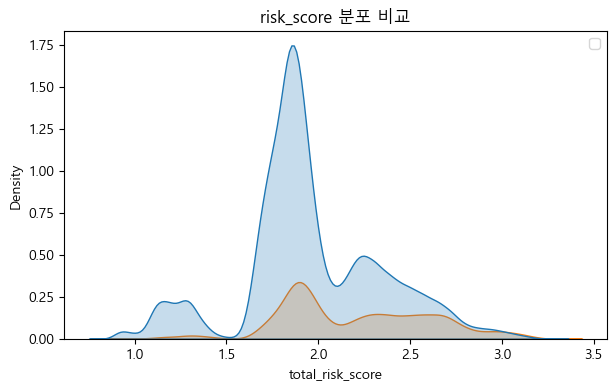

In [146]:
plt.figure(figsize=(7,4))

sns.kdeplot(
    data=df,
    x="total_risk_score",
    hue="default_rate",
    fill=True
)
plt.legend()
plt.title("risk_score 분포 비교")
plt.show()

score_bin
0.7         NaN
0.8    0.011679
0.9    0.027565
1.0    0.035278
1.1    0.042103
1.2    0.066653
1.3    0.111485
1.4    0.204227
1.5    0.082197
1.6    0.077864
1.7    0.111942
1.8    0.150660
1.9    0.209428
2.0    0.237670
2.1    0.193455
2.2    0.216677
2.3    0.259899
2.4    0.290970
2.5    0.340571
2.6    0.396049
2.7    0.430626
2.8    0.420265
2.9    0.448631
3.0    0.518212
3.1    0.589890
Name: default_rate, dtype: float64

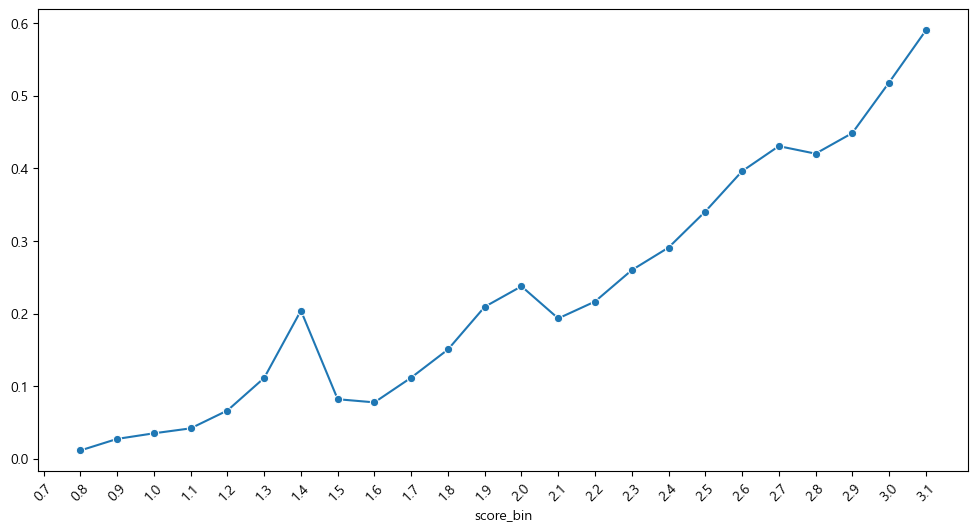

In [147]:
temp = df.copy()
bins = [i / 10 for i in range(7, 33)]   # 0.72 ~ 2.80, edge 리스트
labels = list(range(7, len(bins) +6))        # label은 edge보다 1개 적어야 함
for v,i in enumerate(labels):
    labels[v] = i/10

temp["score_bin"] = pd.cut(temp["total_risk_score"], bins=bins, labels=labels)

risk_curve = temp.groupby("score_bin")["default_rate"].mean()
display(risk_curve)


sns.lineplot(x=risk_curve.index.astype(str),
             y=risk_curve.values,
             marker="o")

plt.xticks(rotation=45)
plt.show()



---------------------------------

In [148]:
def reference_value_print(df,mask, score):
    print(f'기준값 : {mask}')
    mask2 = df[score] >= mask
    print(f'기준값 이상에서의 미상환율 : {df.loc[mask2, 'default_rate'].mean()*100:.4f}%')
    print(f'기준값 미만에서의 미상환율 : {df.loc[~mask2, 'default_rate'].mean()*100:.4f}%')
    print(f'전체 미상환율 : {df['default_rate'].mean()*100:.2f}%')
    print(f'감소된 미상환율: {(df['default_rate'].mean() - df.loc[~mask2, 'default_rate'].mean()) *100:.2f}%')
    print(f'미상환율 감소 비율: {(df['default_rate'].mean() - df.loc[~mask2, 'default_rate'].mean())/(df['default_rate'].mean()) *100:.2f}%')
    print('-'*60)
    print(f'필터링 후 미상환자 수: {(df.loc[~mask2, 'default_rate'].sum())}명')
    print(f'전체 미상환자 수: {(df['default_rate'].sum())}명')
    print(f'줄어든 미상환자 수: {(df['default_rate'].sum())- df.loc[~mask2, 'default_rate'].sum()}명')
    print('-'*60)

    print(f'필터링 후 상환자 수: {len(df.loc[~mask2]) - (df.loc[~mask2, 'default_rate'].sum())}명')
    print(f'전체 상환자 수: {len(df) - (df['default_rate'].sum())}명')
    print(f'줄어든 상환자 수: {(len(df) - (df['default_rate'].sum())) - (len(df.loc[~mask2]) - (df.loc[~mask2, 'default_rate'].sum()))}명')
    print('-'*60)

    print(f'필터링 후 대출자 수: {len(df.loc[~mask2])}명')
    print(f'전체 대출자 수: {len(df)}명')
    

In [149]:
for i in range(7, 33):
    mask = i/10
    reference_value_print(df, mask, 'total_risk_score')
    print('='*80, end='\n\n')

기준값 : 0.7
기준값 이상에서의 미상환율 : 20.1243%
기준값 미만에서의 미상환율 : nan%
전체 미상환율 : 20.12%
감소된 미상환율: nan%
미상환율 감소 비율: nan%
------------------------------------------------------------
필터링 후 미상환자 수: 0명
전체 미상환자 수: 201434명
줄어든 미상환자 수: 201434명
------------------------------------------------------------
필터링 후 상환자 수: 0명
전체 상환자 수: 799517명
줄어든 상환자 수: 799517명
------------------------------------------------------------
필터링 후 대출자 수: 0명
전체 대출자 수: 1000951명

기준값 : 0.8
기준값 이상에서의 미상환율 : 20.1243%
기준값 미만에서의 미상환율 : nan%
전체 미상환율 : 20.12%
감소된 미상환율: nan%
미상환율 감소 비율: nan%
------------------------------------------------------------
필터링 후 미상환자 수: 0명
전체 미상환자 수: 201434명
줄어든 미상환자 수: 201434명
------------------------------------------------------------
필터링 후 상환자 수: 0명
전체 상환자 수: 799517명
줄어든 상환자 수: 799517명
------------------------------------------------------------
필터링 후 대출자 수: 0명
전체 대출자 수: 1000951명

기준값 : 0.9
기준값 이상에서의 미상환율 : 20.1372%
기준값 미만에서의 미상환율 : 1.1679%
전체 미상환율 : 20.12%
감소된 미상환율: 18.96%
미상환율 감소 비율: 94.20%
----------------

- 리스크 점수 만으로 기준을 설정하여 제시하기에는 미상환자 뿐 아니라 제약받는 상환자가 포함될 것으로 생각
- 대출기간별 신용점수기반 그룹별로 리스크 점수의 구간을 나누어 진행

---------------------------------------------------
### 대출기간별 신용점수기반 그룹별로 리스크 점수의 구간 나누기

In [150]:
df.groupby(['term','fico_group', 'default_rate'])['total_risk_score'].agg(
    mean='mean',
    mode=lambda x: x.mode()[0] if not x.mode().empty else None,
    max='max',
    min = 'min',
    range_mid=lambda x: (max(x) + min(x))/2,
    q_75=lambda x: x.quantile(0.75),
)

mean      mode       max       min  \
term      fico_group default_rate                                           
36 months excellent  0             0.995447  0.914326  1.305105  0.827828   
                     1             1.049715  0.901932  1.306189  0.864578   
          fair       0             2.214413  2.369076  2.578988  1.875756   
                     1             2.252237  2.393473  2.609021  1.900698   
          good       0             1.840801  1.921952  2.227803  1.543548   
                     1             1.884475  2.013025  2.234542  1.550020   
          very good  0             1.234642  1.290265  1.639962  1.021414   
                     1             1.296568  1.328188  1.615565  1.040507   
60 months excellent  0             1.654555  1.540102  2.067296  1.402514   
                     1             1.724922  1.644990  2.074970  1.462891   
          fair       0             2.875602  2.970088  3.286642  2.452631   
                     1             2.931643  2.989623  3.331824  2.487974   
          good       0             2.496728  2.257829  2.977132  2.127880   
                     1             2.555974  2.662392  3.004970  2.121744   
          very good  0             1.887250  2.107167  2.332488  1.596345   
                     1             1.958199  2.055281  2.400381  1.617634   

                                   range_mid      q_75  
term      fico_group default_rate                       
36 months excellent  0              1.066466  1.049758  
                     1              1.085383  1.111647  
          fair       0              2.227372  2.282671  
                     1              2.254860  2.321678  
          good       0              1.885676  1.912267  
                     1              1.892281  1.953720  
          very good  0              1.330688  1.303367  
                     1              1.328036  1.366758  
60 months excellent  0              1.734905  1.723633  
                     1              1.768930  1.819335  
          fair       0              2.869637  2.976153  
                     1              2.909899  3.034459  
          good       0              2.552506  2.599199  
                     1              2.563357  2.662904  
          very good  0              1.964416  1.975274  
                     1              2.009007  2.065486

In [151]:
temp = df.copy()
temp['group_by_term_fico'] = np.nan

for i in df['term'].value_counts().index.to_list():
    for v,j in enumerate(df['fico_group'].value_counts().index.to_list()):
        mask = (temp['term'] == i) & (temp['fico_group'] == j)
        temp.loc[mask]
        temp.loc[mask,'group_by_term_fico'] = pd.qcut(temp.loc[mask, 'total_risk_score'], 5, labels=[i+' '+j+ ' ' +str(r+1) for r in range(5)])
test_table = temp.groupby('group_by_term_fico').agg(
    risk_mean = ('total_risk_score', 'mean'),
    default_rate = ('default_rate', 'mean'),
    default_sum = ('default_rate', 'sum'),
    count = ('id', 'count')
    ).reset_index()

display(test_table)


,group_by_term_fico,risk_mean,default_rate,default_sum,count
0,36 months excellent 1,0.902438,0.018498,33,1784
1,36 months excellent 2,0.942268,0.021898,39,1781
2,36 months excellent 3,0.985034,0.038159,68,1782
3,36 months excellent 4,1.038703,0.048233,86,1783
4,36 months excellent 5,1.120788,0.092083,164,1781
5,36 months fair 1,2.078354,0.139377,3965,28448
6,36 months fair 2,2.169594,0.181805,5172,28448
7,36 months fair 3,2.223612,0.205912,5858,28449
8,36 months fair 4,2.277441,0.247302,7035,28447
9,36 months fair 5,2.364434,0.319319,9084,28448


In [152]:
temp = df.copy()
temp['group_name'] = np.nan
temp['group_risk_range'] = np.nan

for i in df['term'].value_counts().index.to_list():
    for v,j in enumerate(df['fico_group'].value_counts().index.to_list()):
        mask = (temp['term'] == i) & (temp['fico_group'] == j)
        temp.loc[mask]
        temp.loc[mask,'group_name'] = pd.qcut(temp.loc[mask, 'total_risk_score'], 5, labels=[i+' '+j+ ' ' +str(r+1) for r in range(5)])
        temp.loc[mask,'group_risk_range'] = pd.qcut(temp.loc[mask, 'total_risk_score'], 5)
temp['group_risk_range'] = temp['group_risk_range'].apply(lambda x: f'({x.left:.2f}, {x.right:.2f}]')
test_table = temp.groupby(['group_name','group_risk_range']).agg(
    risk_mean = ('total_risk_score', 'mean'),
    default_rate = ('default_rate', 'mean'),
    default_sum = ('default_rate', 'sum'),
    count = ('id', 'count')
    ).reset_index()
for i in range(8):
    display(test_table[i*5:(i+1)*5])

,group_name,group_risk_range,risk_mean,default_rate,default_sum,count
0,36 months excellent 1,"(0.83, 0.93]",0.902438,0.018498,33,1784
1,36 months excellent 2,"(0.93, 0.96]",0.942268,0.021898,39,1781
2,36 months excellent 3,"(0.96, 1.01]",0.985034,0.038159,68,1782
3,36 months excellent 4,"(1.01, 1.07]",1.038703,0.048233,86,1783
4,36 months excellent 5,"(1.07, 1.31]",1.120788,0.092083,164,1781


,group_name,group_risk_range,risk_mean,default_rate,default_sum,count
5,36 months fair 1,"(1.88, 2.14]",2.078354,0.139377,3965,28448
6,36 months fair 2,"(2.14, 2.20]",2.169594,0.181805,5172,28448
7,36 months fair 3,"(2.20, 2.25]",2.223612,0.205912,5858,28449
8,36 months fair 4,"(2.25, 2.31]",2.277441,0.247302,7035,28447
9,36 months fair 5,"(2.31, 2.61]",2.364434,0.319319,9084,28448


,group_name,group_risk_range,risk_mean,default_rate,default_sum,count
10,36 months good 1,"(1.54, 1.75]",1.697848,0.089683,9691,108058
11,36 months good 2,"(1.75, 1.82]",1.792240,0.123792,13377,108060
12,36 months good 3,"(1.82, 1.88]",1.852237,0.149843,16192,108060
13,36 months good 4,"(1.88, 1.94]",1.905763,0.185771,20072,108047
14,36 months good 5,"(1.94, 2.23]",1.990704,0.247249,26717,108057


,group_name,group_risk_range,risk_mean,default_rate,default_sum,count
15,36 months very good 1,"(1.02, 1.15]",1.109433,0.027746,390,14056
16,36 months very good 2,"(1.15, 1.21]",1.175217,0.047978,674,14048
17,36 months very good 3,"(1.21, 1.27]",1.237915,0.062233,875,14060
18,36 months very good 4,"(1.27, 1.32]",1.295057,0.079775,1121,14052
19,36 months very good 5,"(1.32, 1.64]",1.378416,0.149388,2098,14044


,group_name,group_risk_range,risk_mean,default_rate,default_sum,count
20,60 months excellent 1,"(1.40, 1.56]",1.517915,0.057416,24,418
21,60 months excellent 2,"(1.56, 1.62]",1.592459,0.098321,41,417
22,60 months excellent 3,"(1.62, 1.68]",1.650735,0.112710,47,417
23,60 months excellent 4,"(1.68, 1.76]",1.718135,0.170264,71,417
24,60 months excellent 5,"(1.76, 2.08]",1.842289,0.249400,104,417


,group_name,group_risk_range,risk_mean,default_rate,default_sum,count
25,60 months fair 1,"(2.45, 2.77]",2.698912,0.283136,2290,8088
26,60 months fair 2,"(2.77, 2.86]",2.817870,0.363389,2938,8085
27,60 months fair 3,"(2.86, 2.94]",2.901151,0.404897,3274,8086
28,60 months fair 4,"(2.94, 3.03]",2.982124,0.475454,3845,8087
29,60 months fair 5,"(3.03, 3.33]",3.094722,0.556270,4498,8086


,group_name,group_risk_range,risk_mean,default_rate,default_sum,count
30,60 months good 1,"(2.12, 2.38]",2.319894,0.203981,7246,35523
31,60 months good 2,"(2.38, 2.47]",2.430104,0.268617,9541,35519
32,60 months good 3,"(2.47, 2.56]",2.513271,0.319135,11336,35521
33,60 months good 4,"(2.56, 2.65]",2.600028,0.371256,13187,35520
34,60 months good 5,"(2.65, 3.00]",2.716762,0.464317,16493,35521


,group_name,group_risk_range,risk_mean,default_rate,default_sum,count
35,60 months very good 1,"(1.60, 1.78]",1.731188,0.100026,383,3829
36,60 months very good 2,"(1.78, 1.85]",1.816488,0.141662,542,3826
37,60 months very good 3,"(1.85, 1.92]",1.885705,0.180298,690,3827
38,60 months very good 4,"(1.92, 2.03]",1.971445,0.234649,898,3827
39,60 months very good 5,"(2.03, 2.40]",2.101711,0.333159,1275,3827


- default_rate 기반으로 각 그룹을 나누는 것보단 각 조합에서의 risk_score를 바탕으로 위험율에 기반하여 제안을 하는 것으로 결정!

-------------------------------------------

### test 데이터로 확인

In [153]:
test_df = pd.read_csv('test_df.csv', encoding='utf-8',parse_dates=['issue_d', 'earliest_cr_line'])

In [154]:
len(test_df), len(df)

(250238, 1000951)

In [155]:
display(test_df.groupby('default_rate')['total_risk_score'].mean())
display(df.groupby('default_rate')['total_risk_score'].mean())

default_rate
0    1.963011
1    2.206991
Name: total_risk_score, dtype: float64

default_rate
0    1.963649
1    2.206031
Name: total_risk_score, dtype: float64

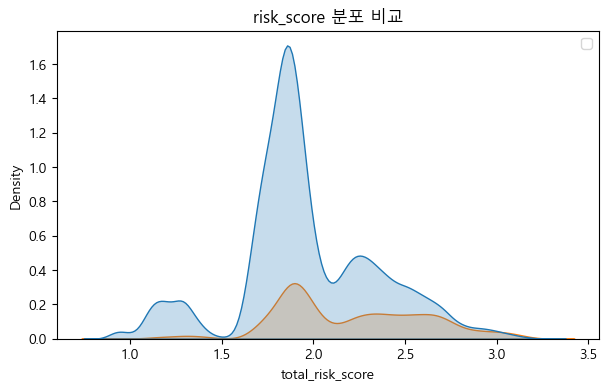

In [156]:
plt.figure(figsize=(7,4))

sns.kdeplot(
    data=test_df,
    x="total_risk_score",
    hue="default_rate",
    fill=True
)
plt.legend()
plt.title("risk_score 분포 비교")
plt.show()

score_bin
0.7         NaN
0.8    0.005780
0.9    0.011342
1.0    0.034769
1.1    0.042184
1.2    0.063196
1.3    0.104489
1.4    0.218970
1.5    0.066563
1.6    0.078041
1.7    0.112249
1.8    0.150840
1.9    0.208218
2.0    0.237939
2.1    0.193937
2.2    0.216981
2.3    0.260382
2.4    0.296960
2.5    0.334086
2.6    0.395595
2.7    0.434354
2.8    0.436393
2.9    0.445545
3.0    0.524859
3.1    0.590909
Name: default_rate, dtype: float64

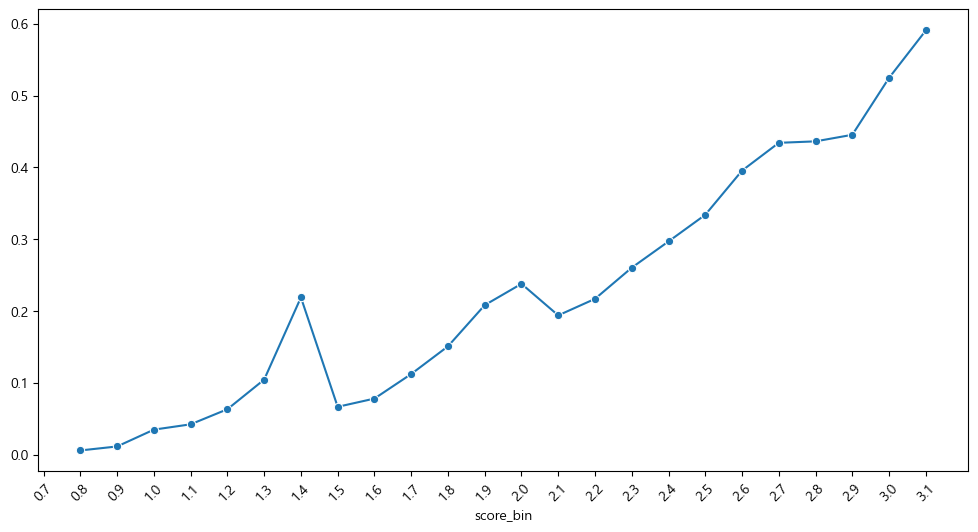

In [157]:
temp = test_df.copy()
bins = [i / 10 for i in range(7, 33)]   # 0.72 ~ 2.80, edge 리스트
labels = list(range(7, len(bins) +6))        # label은 edge보다 1개 적어야 함
for v,i in enumerate(labels):
    labels[v] = i/10

temp["score_bin"] = pd.cut(temp["total_risk_score"], bins=bins, labels=labels)

risk_curve = temp.groupby("score_bin")["default_rate"].mean()
display(risk_curve)


sns.lineplot(x=risk_curve.index.astype(str),
             y=risk_curve.values,
             marker="o")

plt.xticks(rotation=45)
plt.show()


In [158]:
for i in range(7, 33):
    mask = i/10
    reference_value_print(test_df, mask, 'total_risk_score')
    print('='*80, end='\n\n')

기준값 : 0.7
기준값 이상에서의 미상환율 : 20.1242%
기준값 미만에서의 미상환율 : 50.0000%
전체 미상환율 : 20.12%
감소된 미상환율: -29.88%
미상환율 감소 비율: -148.45%
------------------------------------------------------------
필터링 후 미상환자 수: 1명
전체 미상환자 수: 50359명
줄어든 미상환자 수: 50358명
------------------------------------------------------------
필터링 후 상환자 수: 1명
전체 상환자 수: 199879명
줄어든 상환자 수: 199878명
------------------------------------------------------------
필터링 후 대출자 수: 2명
전체 대출자 수: 250238명

기준값 : 0.8
기준값 이상에서의 미상환율 : 20.1242%
기준값 미만에서의 미상환율 : 50.0000%
전체 미상환율 : 20.12%
감소된 미상환율: -29.88%
미상환율 감소 비율: -148.45%
------------------------------------------------------------
필터링 후 미상환자 수: 1명
전체 미상환자 수: 50359명
줄어든 미상환자 수: 50358명
------------------------------------------------------------
필터링 후 상환자 수: 1명
전체 상환자 수: 199879명
줄어든 상환자 수: 199878명
------------------------------------------------------------
필터링 후 대출자 수: 2명
전체 대출자 수: 250238명

기준값 : 0.9
기준값 이상에서의 미상환율 : 20.1377%
기준값 미만에서의 미상환율 : 1.1429%
전체 미상환율 : 20.12%
감소된 미상환율: 18.98%
미상환율 감소 비율: 94.32%
